In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr


In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    521 non-null    float64
 1   ztfname                           521 non-null    object 
 2   ZTF_redshift                      521 non-null    float64
 3   ZTF_redshift_err                  521 non-null    float64
 4   ZTF_source                        521 non-null    object 
 5   ZTF_t0                            521 non-null    float64
 6   ZTF_x0                            521 non-null    float64
 7   ZTF_x1                            521 non-null    float64
 8   ZTF_c                             521 non-null    float64
 9   ZTF_t0_err                        521 non-null    float64
 10  ZTF_x0_err                        521 non-null    float64
 11  ZTF_x1_err                        521 non-null    float64
 12  ZTF_c_er

## Correlation Matrix Analysis — Notes for Paper

**Purpose:** This Spearman ρ correlation matrix goes in §3.1 (Methods → Feature Screening) as motivation for why ML is needed.

### Key Takeaways

**2. x0 and t0 carry no host-galaxy physics — exclude from ML training:**
- x0 is just a distance proxy (ρ = −0.84 with both redshifts). Already absorbed into μ_obs.
- t0 is the calendar date of maximum light — correlated with nothing (all |ρ| ≤ 0.08).

**3. x1 has strong cross-correlations with DESI host properties:**
- x1 vs log M★: −0.40
- x1 vs DN4000: −0.41
- x1 vs g−r: −0.48
- x1 vs Age: −0.39

This is the known stretch-age relation: massive, old, red hosts produce faster-declining (low x1) SNe Ia. The Tripp equation applies one global α regardless of host environment. If α actually varies with host mass or age, the linear correction is systematically wrong → leftover error in Hubble residuals. **This is the cross-term our paper is designed to detect.**

**4. c has weaker but nonzero cross-correlations with hosts:**
- c vs log M★: 0.20
- c vs g−r: 0.15

This is the dust correlation: more massive galaxies have more dust → redder SNe. Same argument applies — if β varies with host properties (Kelsey+2023 found ~3σ differences in β between high/low mass environments), the linear Tripp correction leaves residual bias.

**5. DESI host properties are strongly intercorrelated (the "tangle"):**
- log M★ vs g−r: 0.76
- log M★ vs Age: 0.75
- DN4000 vs g−r: 0.79
- DN4000 vs Age: 0.63
- g−r vs Age: 0.74
- log M★ vs DN4000: 0.64

These all trace the galaxy mass-metallicity-age sequence. A univariate correction (e.g., mass step at log M★ = 10) cannot disentangle which property is actually driving the Hubble residual bias because they all move together. **This is why nonparametric ML is needed.**

**6. SFR and σ_v are the independent ones:**
Both are weakly correlated with the log M★ / DN4000 / g−r / Age block (|ρ| ≤ 0.26). They may carry independent information about the SN Ia progenitor environment that the other four DESI properties don't capture.

### Decisions for the Paper
- **Include in ML training:** c, x1, log M★, SFR, σ_v, DN4000, g−r, Age, z (9 features)
- **Exclude from ML training:** x0 (distance proxy), t0 (no information)
- **This figure goes in:** §3.1 Methods (Feature Screening), NOT Results
- **The argument it supports:** Linear corrections can't handle intercorrelated features with potential cross-terms → need ML

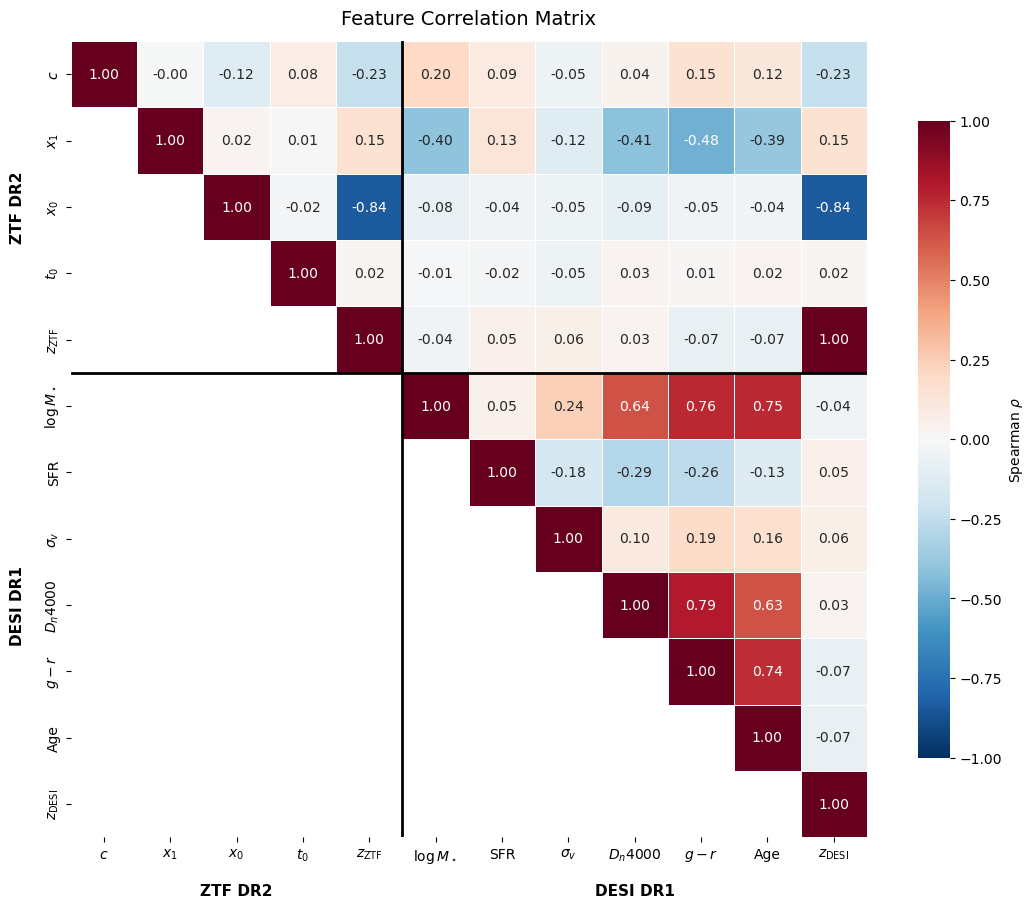

In [ ]:
# ──────────────────────────────────────────────────────────────
# Define features grouped by source
# ──────────────────────────────────────────────────────────────

# --- ZTF DR2 light-curve parameters ---
ztf_cols   = ["ZTF_c", "ZTF_x1", "ZTF_x0", "ZTF_t0", "ZTF_redshift"]
ztf_labels = [r"$c$", r"$x_1$", r"$x_0$", r"$t_0$", r"$z_{\rm ZTF}$"]

# --- DESI DR1 FastSpecFit host galaxy properties ---
desi_cols   = ["DESI_FASTSPEC_LOGMSTAR", "DESI_FASTSPEC_SFR", "DESI_FASTSPEC_VDISP",
               "DESI_FASTSPEC_DN4000", "DESI_FASTSPEC_g_minus_r", "DESI_FASTSPEC_AGE",
               "DESI_METADATA_Z"]
desi_labels = [r"$\log M_\star$", "SFR", r"$\sigma_v$", r"$D_n4000$", r"$g - r$", "Age",
               r"$z_{\rm DESI}$"]

# Combined: ZTF first, then DESI
feature_cols   = ztf_cols + desi_cols
display_labels = ztf_labels + desi_labels
n_ztf  = len(ztf_cols)
n_desi = len(desi_cols)
n_all  = n_ztf + n_desi

# ──────────────────────────────────────────────────────────────
# Compute Spearman rho and p-values via scipy
# ──────────────────────────────────────────────────────────────
data_matrix = df[feature_cols].values
rho_matrix, pval_matrix = spearmanr(data_matrix)

spearman_corr = pd.DataFrame(rho_matrix, index=display_labels, columns=display_labels)
spearman_pval = pd.DataFrame(pval_matrix, index=display_labels, columns=display_labels)

# Mask the lower triangle
mask = np.tril(np.ones_like(spearman_corr, dtype=bool), k=-1)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": r"Spearman $\rho$", "shrink": 0.8},
    ax=ax,
)

# Thick lines separating ZTF and DESI blocks
ax.axhline(n_ztf, color="black", linewidth=2)
ax.axvline(n_ztf, color="black", linewidth=2)

# Group labels — left margin
ax.text(-0.8, n_ztf / 2, "ZTF DR2",
        ha="center", va="center", fontsize=11, fontweight="bold",
        rotation=90, transform=ax.transData)
ax.text(-0.8, n_ztf + n_desi / 2, "DESI DR1",
        ha="center", va="center", fontsize=11, fontweight="bold",
        rotation=90, transform=ax.transData)

# Group labels — bottom margin
ax.text(n_ztf / 2, n_all + 0.8, "ZTF DR2",
        ha="center", va="center", fontsize=11, fontweight="bold",
        transform=ax.transData)
ax.text(n_ztf + n_desi / 2, n_all + 0.8, "DESI DR1",
        ha="center", va="center", fontsize=11, fontweight="bold",
        transform=ax.transData)

ax.set_title("Feature Correlation Matrix", fontsize=14, pad=12)
fig.tight_layout()
plt.show()

# Spearman Rho #

Four of the six DESI host galaxy properties show statistically significant monotonic correlations with the Hubble residuals: g−r (ρ = −0.303), DN4000 (−0.276), log M★ (−0.269), and Age (−0.219), all with p < 10⁻⁷. The negative sign means redder, older, more massive hosts with stronger 4000 Å breaks produce SNe Ia that are brighter after Tripp correction — consistent with the direction of the known mass step. Notably, g−r is the strongest correlate, not stellar mass, echoing Kelsey et al. (2023)'s finding that galaxy color removes more Hubble residual dispersion than mass. Velocity dispersion and SFR show no significant individual correlation (p > 0.29), though they may still carry information through interactions with other features.

In [ ]:
# ──────────────────────────────────────────────────────────────
# Spearman rho: HOST GALAXY properties vs. Hubble residuals
# ──────────────────────────────────────────────────────────────
host_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
]

target = df["residuals"]

rows = []
for col in host_cols:
    rho, pval = spearmanr(df[col], target)
    rows.append({"Feature": col, "Spearman ρ": rho, "p-value": pval})

rho_table = pd.DataFrame(rows)
rho_table["Spearman ρ"] = rho_table["Spearman ρ"].round(3)
rho_table["p-value"] = rho_table["p-value"].map(lambda x: f"{x:.2e}")
rho_table = rho_table.sort_values("Spearman ρ", key=abs, ascending=False)

print(rho_table.to_string(index=False))

                Feature  Spearman ρ  p-value
DESI_FASTSPEC_g_minus_r      -0.303 1.54e-12
   DESI_FASTSPEC_DN4000      -0.276 1.36e-10
 DESI_FASTSPEC_LOGMSTAR      -0.269 4.19e-10
      DESI_FASTSPEC_AGE      -0.219 4.40e-07
    DESI_FASTSPEC_VDISP      -0.046 2.92e-01
      DESI_FASTSPEC_SFR       0.015 7.31e-01
